# Clustering

Categorization without labels

## Recap: Psychological Models of Categorization

<div style="display: flex; align-items: center; gap: 2em;">
<div style="flex: 0 0 45%;">
<img src="figures/prototypes_1.png" width="400" />
</div>
<div style="flex: 0 0 50%;">

Prototypes $\boldsymbol{\mu}_{\Delta}$ and $\boldsymbol{\mu}_{o}$:

$$\boldsymbol{\mu}_{\Delta} = \frac{1}{N_{\Delta}}\sum_n^{N_{\Delta}} \mathbf{x}_{\Delta,n}$$

$$\boldsymbol{\mu}_{o} = \frac{1}{N_{o}}\sum_n^{N_o} \mathbf{x}_{o,n}$$

New data points $x$ are assigned to their closest cluster center $\mu^*$:

$$\boldsymbol{\mu}^* = \operatorname{argmin}_i(\|\boldsymbol{\mu}_i - \mathbf{x}\|_2)$$

</div>
</div>

<div style="display: flex; align-items: center; gap: 2em;">
<div style="flex: 0 0 45%;">
<img src="figures/prototypes_2.png" width="400" />
</div>
<div style="flex: 0 0 50%;">

The only difference for clustering is:

**We do not have labels.**

</div>
</div>

## Clustering For Quantization of Analog Signals

<div style="text-align: center;">
<img src="figures/quantization_figure.pdf" width="600" />
</div>

Quantization transforms an analog signal into discretized states.

This is important for Audio Processing, Compression, ...

The most popular Clustering Algorithm was proposed for Quantization (Lloyd, 1957).

## K-means Clustering

> **K-Means Algorithm** — Re-iterating two steps:
>
> 1. Assign each data point $\mathbf{x}_i$ to their closest cluster $\boldsymbol{\mu}_k$
> 2. Update $\boldsymbol{\mu}_k$ to the mean of the members in that cluster

## K-means Clustering

**Goal:** Given data $\mathbf{x}_1,\dots,\mathbf{x}_N$ find cluster centers $\boldsymbol{\mu}_1, \ldots, \boldsymbol{\mu}_K$ such that the distances of data points to their respective cluster centre are minimized:

$$\mathcal{J} = \sum_{n=1}^N \sum_{k=1}^K \mathbf{c}_{n,k} \| \mathbf{x}_n - \boldsymbol{\mu}_{\mathbf{c}_k} \|$$

where

$$\mathbf{c}_{n,k} = \begin{cases} 1 & \text{if } \mathbf{x}_n \text{ belongs to cluster } k \\ 0 & \text{otherwise} \end{cases}$$

## Online K-Means

$$\mathcal{E}(\boldsymbol{\mu}_k) = \frac{1}{2} (\mathbf{x}-\boldsymbol{\mu}_k)^2$$

$$= \frac{1}{2}\mathbf{x}^\top\mathbf{x} - \frac{1}{2}2 \mathbf{x}^\top \boldsymbol{\mu}_k - \frac{1}{2}\boldsymbol{\mu}_k^\top\boldsymbol{\mu}_k$$

$$\frac{\partial \mathcal{E}(\boldsymbol{\mu}_k)}{\partial \boldsymbol{\mu}_k} = \boldsymbol{\mu}_k - \mathbf{x}$$

Learning rate: $\eta = \frac{1}{n_k}$ &nbsp;&nbsp; ($n_k$ = number of samples in cluster $k$)

Gradient Step:

$$\boldsymbol{\mu}_k \leftarrow \boldsymbol{\mu}_k - \eta \frac{\partial \mathcal{E}(\boldsymbol{\mu}_k)}{\partial \boldsymbol{\mu}_k} = \boldsymbol{\mu}_k - \frac{1}{n_k} (\mathbf{x} - \boldsymbol{\mu}_k)$$

## Online K-Means Algorithm

**Algorithm: Online K-means clustering**

**Require:** data points $\mathbf{x}_1, \ldots, \mathbf{x}_n \in \mathbb{R}^d$, number of clusters $k$, iterations $m$.

**Ensure:** cluster centres $\boldsymbol{\mu}_1, \ldots, \boldsymbol{\mu}_k \in \mathbb{R}^{d}$

1. Choose random data points as initial cluster centres: $\boldsymbol{\mu}_1 \gets \mathbf{x}_{i_1}, \ldots, \boldsymbol{\mu}_k \gets \mathbf{x}_{i_k}$ where $i_j \neq i_l$ for all $j \neq l$.
2. Initialize cluster assignment counts $n_1, \ldots, n_k \gets 0$
3. **For** $i = 1, \ldots, m$:
   - Draw a new data point randomly: $\mathbf{x}_i$
   - Find nearest cluster centre: $k^* \gets \operatorname{argmin}_{k} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|_2$
   - Update cluster counts: $n_{k^*} \gets n_{k^*} + 1$
   - Update cluster centres: $\boldsymbol{\mu}_{k^*} \gets \boldsymbol{\mu}_{k^*} + \frac{1}{n_{k^*}} (\mathbf{x}_i - \boldsymbol{\mu}_{k^*})$

In [96]:
class KMeans:

    def __init__(self, n_clusters=2, iterations=20):
        # number of clusters
        self.n_clusters = n_clusters
        self.iterations = iterations
        # centroids
        self.cluster_centers = None

    def fit(self, X):
        # initialize with random data points
        D,N = X.shape[1],X.shape[0]
        # draw random data points to initialize clusters
        if self.cluster_centers == None:
            self.cluster_centers = X[np.random.choice(N, self.n_clusters)]
        counts = np.zeros((self.n_clusters))
        for it in range(np.minimum(self.iterations,N)):
            # draw random data point
            idx = np.random.choice(N)
            # find closest cluster
            cidx = self.predict(X[[idx],:])[0]
            # update counts
            counts[cidx] += 1
            # update cluster center
            self.cluster_centers[cidx,:] += 1/counts[cidx] * (X[idx,:] - self.cluster_centers[cidx,:])
        
    def predict(self, X):
        # compute distance to all centroids
        dist_to_centroids = np.zeros((X.shape[0], self.n_clusters))
        for c_idx in range(self.n_clusters):
            dist_to_centroids[:,c_idx] = np.sum((X - self.cluster_centers[c_idx,:]) ** 2, axis=1)
        return dist_to_centroids.argsort(axis=1)[:,0]

### Online K-Means Algorithm — Example (Iteration 0)

<div style="text-align: center;">
<img src="figures/okmeans-it-0.pdf" width="400" />
</div>

### Online K-Means Algorithm — Example (Iteration 5)

<div style="text-align: center;">
<img src="figures/okmeans-it-5.pdf" width="400" />
</div>

### Online K-Means Algorithm — Example (Iteration 10)

<div style="text-align: center;">
<img src="figures/okmeans-it-10.pdf" width="400" />
</div>

### Online K-Means Algorithm — Example (Iteration 30)

<div style="text-align: center;">
<img src="figures/okmeans-it-30.pdf" width="400" />
</div>

## Application Example: Geyser Eruptions

<div style="display: flex; align-items: flex-start; gap: 2em;">
<div style="flex: 0 0 40%; text-align: center;">
<img src="figures/oldFaithful.jpg" width="320" />

*Old Faithful Geyser, Yellowstone National Park, USA*
</div>
<div style="flex: 0 0 55%;">

Famous data set for clustering:

- **Old Faithful Eruptions**
- Two dimensions:
  1. Time of Eruption [mins]
  2. Time until next Eruption [mins]

</div>
</div>

In [99]:
import matplotlib.pylab as plt
import numpy as np
from numpy.random import multivariate_normal as mvn
%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (5.0, 5.0)

# eruptions	waiting
from io import StringIO
# Your TSV formatted string
tsv_data = '''eruptions	waiting
1.800	54
3.333	74
2.283	62
4.533	85
2.883	55
4.700	88
3.600	85
1.950	51
4.350	85
1.833	54
3.917	84
4.200	78
1.750	47
4.700	83
2.167	52
1.750	62
4.800	84
1.600	52
4.250	79
1.800	51
1.750	47
3.450	78
3.067	69
4.533	74
3.600	83
1.967	55
4.083	76
3.850	78
4.433	79
4.300	73
4.467	77
3.367	66
4.033	80
3.833	74
2.017	52
1.867	48
4.833	80
1.833	59
4.783	90
4.350	80
1.883	58
4.567	84
1.750	58
4.533	73
3.317	83
3.833	64
2.100	53
4.633	82
2.000	59
4.800	75
4.716	90
1.833	54
4.833	80
1.733	54
4.883	83
3.717	71
1.667	64
4.567	77
4.317	81
2.233	59
4.500	84
1.750	48
4.800	82
1.817	60
4.400	92
4.167	78
4.700	78
2.067	65
4.700	73
4.033	82
1.967	56
4.500	79
4.000	71
1.983	62
5.067	76
2.017	60
4.567	78
3.883	76
3.600	83
4.133	75
4.333	82
4.100	70
2.633	65
4.067	73
4.933	88
3.950	76
4.517	80
2.167	48
4.000	86
2.200	60
4.333	90
1.867	50
4.817	78
1.833	63
4.300	72
4.667	84
3.750	75
1.867	51
4.900	82
2.483	62
4.367	88
2.100	49
4.500	83
4.050	81
1.867	47
4.700	84
1.783	52
4.850	86
3.683	81
4.733	75
2.300	59
4.900	89
4.417	79
1.700	59
4.633	81
2.317	50
4.600	85
1.817	59
4.417	87
2.617	53
4.067	69
4.250	77
1.967	56
4.600	88
3.767	81
1.917	45
4.500	82
2.267	55
4.650	90
1.867	45
4.167	83
2.800	56
4.333	89
1.833	46
4.383	82
1.883	51
4.933	86
2.033	53
3.733	79
4.233	81
2.233	60
4.533	82
4.817	77
4.333	76
1.983	59
4.633	80
2.017	49
5.100	96
1.800	53
5.033	77
4.000	77
2.400	65
4.600	81
3.567	71
4.000	70
4.500	81
4.083	93
1.800	53
3.967	89
2.200	45
4.150	86
2.000	58
3.833	78
3.500	66
4.583	76
2.367	63
5.000	88
1.933	52
4.617	93
1.917	49
2.083	57
4.583	77
3.333	68
4.167	81
4.333	81
4.500	73
2.417	50
4.000	85
4.167	74
1.883	55
4.583	77
4.250	83
3.767	83
2.033	51
4.433	78
4.083	84
1.833	46
4.417	83
2.183	55
4.800	81
1.833	57
4.800	76
4.100	84
3.966	77
4.233	81
3.500	87
4.366	77
2.250	51
4.667	78
2.100	60
4.350	82
4.133	91
1.867	53
4.600	78
1.783	46
4.367	77
3.850	84
1.933	49
4.500	83
2.383	71
4.700	80
1.867	49
3.833	75
3.417	64
4.233	76
2.400	53
4.800	94
2.000	55
4.150	76
1.867	50
4.267	82
1.750	54
4.483	75
4.000	78
4.117	79
4.083	78
4.267	78
3.917	70
4.550	79
4.083	70
2.417	54
4.183	86
2.217	50
4.450	90
1.883	54
1.850	54
4.283	77
3.950	79
2.333	64
4.150	75
2.350	47
4.933	86
2.900	63
4.583	85
3.833	82
2.083	57
4.367	82
2.133	67
4.350	74
2.200	54
4.450	83
3.567	73
4.500	73
4.150	88
3.817	80
3.917	71
4.450	83
2.000	56
4.283	79
4.767	78
4.533	84
1.850	58
4.250	83
1.983	43
2.250	60
4.750	75
4.117	81
2.150	46
4.417	90
1.817	46
4.467	74'''

## Old Faithful Data

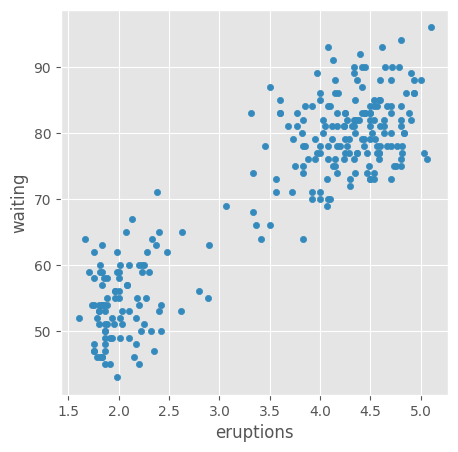

In [100]:
X = pd.read_csv(StringIO(tsv_data), sep='\t')
X.plot.scatter('eruptions', 'waiting');

## KMeans on Old Faithful Data

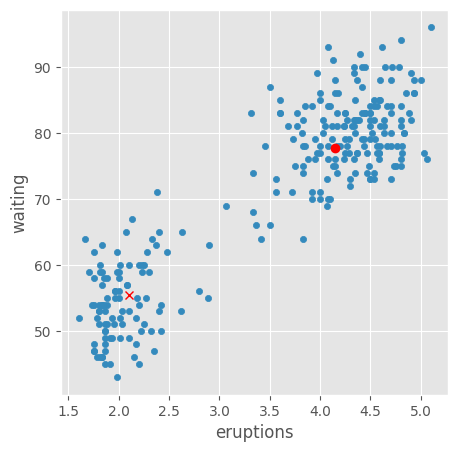

In [101]:
kmeans = KMeans(n_clusters = 2)
kmeans.fit(X.values)
X.plot.scatter('eruptions', 'waiting');
plt.plot(kmeans.cluster_centers[0,0], kmeans.cluster_centers[0,1],'ro',
kmeans.cluster_centers[1,0], kmeans.cluster_centers[1,1],'rx');

## Clustering Instability

Number of Clusters is a critical parameter.

<div style="text-align: center;">
<img src="figures/instability.png" width="480" />
</div>

Clusterings are instable if number of clusters is too small or too large (Luxburg, 2009)


- Number of clusters is critical hyper parameter
- In supervised settings we use cross-validation to optimize hyper-parameters for accuracy on test data
- How can we optimize the number of clusters?
- $\rightarrow$ Choose that $k$ that results in most **stable** clusterings

For a review see e.g. Luxburg (2009).

### Clustering Instability Algorithm

**Algorithm: Clustering Instability**

**Require:** data points $\mathbf{x}_1, \ldots, \mathbf{x}_n \in \mathbb{R}^d$, clustering algorithm $\mathcal{A}$, maximal number of clusters $K$, iterations $i$.

**Ensure:** optimal number of clusters $k^*$

1. **For** $k = 2$ to $K$:
   - Resample data set (e.g. random draws with replacement)
   - **For** $it = 1$ to $i$:
     - Cluster data using algorithm $\mathcal{A}$ into $k$ clusters
   - Compute minimal (across all label permutations) distance between clusterings
2. Choose that $k$ that has the minimal instability over resamplings.

## Application: Clustering 'Mentality' of German Population

- Until 1989 Germany was divided into
  - a free capitalistic western part
  - a communist eastern part
- Political systems influence mentality of people
- The survey **"Perspektive Deutschland"** investigated this
- Survey asked questions about:
  - what people desire
  - what people are afraid of

### German Regions clustered by 'Mentality' of Population

<div style="text-align: center;">
<img src="figures/mentalitaet.png" width="400" />
</div>

...based on questionnaires, 'Perspektive Deutschland' poll 2005.

### German Regions clustered by 'Mentality' of Population

<div style="display: flex; align-items: flex-start; gap: 2em;">
<div style="flex: 0 0 40%;">
<img src="figures/mentalitaet.png" width="320" />
</div>
<div style="flex: 0 0 55%;">

**People in cluster 1 say:**
- Helping others is important
- I am afraid of losing my job

**People in cluster 2 say:**
- Reaching my own goals is important
- I am afraid of losing my health

</div>
</div>

## Distance Measures for Real-Valued Data $\mathbf{x} \in \mathbb{R}^D$

Clustering Algorithms need a **distance function** $d(\mathbf{x}_i, \mathbf{x}_j)$.

- For real valued data $\mathbf{x} \in \mathbb{R}^D$ we can use the **Euclidean distance**:

$$d(\mathbf{x}_i,\mathbf{x}_j) = \|\mathbf{x}_i-\mathbf{x}_j\|_2^2$$

- More robust (less sensitive to outliers): the **city block distance** or $\mathcal{L}_1$ norm:

$$d(\mathbf{x}_i,\mathbf{x}_j) = \|\mathbf{x}_i-\mathbf{x}_j\|_1$$

- Another alternative: the **correlation coefficient** (cosine similarity):

$$d(\mathbf{x}_i,\mathbf{x}_j) = \frac{\mathbf{x}_1^\top\mathbf{x}_2}{\|\mathbf{x}_1\|_2\|\mathbf{x}_2\|_2}$$

For standardized data $\sum_i \mathbf{x}_i = 0,~\sum_i \mathbf{x}_i^2 = 1$: maximizing correlation = minimizing euclidean distance.

## Distance Measures for Non-Real-Valued Data

- For **ordinal variables** $\mathbf{x} \in \{\text{low}, \text{medium}, \text{high}\}^D$: transform into real-valued numbers (e.g. $1/3, 2/3, 3/3$) and apply real-valued distance functions.

- For **categorical variables** $\mathbf{x} \in \{\text{red}, \text{green}, \text{blue}\}^D$: use binary coding for the differences:

$$d(\mathbf{x}_i,\mathbf{x}_j) = \sum_d^D \mathbf{x}_{id} \neq \mathbf{x}_{jd}$$

  This metric is called the **Hamming Distance**.

For the sake of simplicity we only consider the Euclidean distance.

## Hierarchical Clustering

- K-Means produces **flat** clusterings
- Often we are interested in a **hierarchy** of clusterings
- Examples:
  - Biological Species
  - Topics in Text Documents
 
- Options:
    - Bottom Up: Agglomerative Clustering
    - Top Down: Recursive K-Means

## Hierarchical Clustering

- A popular approach to hierarchical clustering:
  1. Start with each data point as one cluster
  2. Successively merge (*agglomerate*) similar clusters
- $\rightarrow$ **Agglomerative Clustering**
- As most clustering algorithms, these procedures are not defined via objective functions but via algorithms
- $\rightarrow$ Difficult to establish convergence criteria

## Recursive K-Means Clustering

- Define Branching Factor (=number of clusters)
- Run K-Means
    - While there are more datapoints than clusters:
        - For all Clusters:
            - Run K-Means again 

## Summary

- Clustering Algorithms find clusters in data
- Clustering Performance depends on distance function used
- K-Means is one of the most popular clustering algorithms
- For large data sets use **Online K-Means**
- Wrong number of clusters leads to **unstable** results
- **Hierarchical clustering** produces trees of clusterings

## References

- Bishop, C. M. *Pattern Recognition and Machine Learning*. Springer, 2006.
- Lloyd, S. P. (1957). *Least squares quantization in PCM*. Bell Laboratories Technical Report.
- Luxburg, U. v. (2009). *Clustering stability: An overview*. Foundations and Trends in Machine Learning, 2(3), 235–274.
- Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective*. MIT Press.